<a href="https://colab.research.google.com/github/rudranarayan6371/Hawkins-file-exchange/blob/main/Copy_of_Project1005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


In [ ]:
# Load the dataset
df = pd.read_excel("/content/Real estate valuation data set.xlsx")
print("Shape:", df.shape)
df.head()


Shape: (414, 8)


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
# Rename columns to clean, code-friendly names
df = df.rename(columns={
    "No": "id",
    "X1 transaction date": "transaction_date",
    "X2 house age": "house_age",
    "X3 distance to the nearest MRT station": "dist_to_mrt",
    "X4 number of convenience stores": "num_convenience_stores",
    "X5 latitude": "latitude",
    "X6 longitude": "longitude",
    "Y house price of unit area": "price_per_unit_area",
})

df = df.drop(columns=["id"])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_date        414 non-null    float64
 1   house_age               414 non-null    float64
 2   dist_to_mrt             414 non-null    float64
 3   num_convenience_stores  414 non-null    int64  
 4   latitude                414 non-null    float64
 5   longitude               414 non-null    float64
 6   price_per_unit_area     414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [ ]:
# Check for missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
transaction_date          0
house_age                 0
dist_to_mrt               0
num_convenience_stores    0
latitude                  0
longitude                 0
price_per_unit_area       0
dtype: int64

Duplicate rows: 0


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
transaction_date,414.0,2013.148953,0.281995,2012.666667,2012.916667,2013.166667,2013.416667,2013.583333
house_age,414.0,17.712560,11.392485,0.000000,9.025000,16.100000,28.150000,43.800000
dist_to_mrt,414.0,1083.885689,1262.109595,23.382840,289.324800,492.231300,1454.279000,6488.021000
num_convenience_stores,414.0,4.094203,2.945562,0.000000,1.000000,4.000000,6.000000,10.000000
latitude,414.0,24.969030,0.012410,24.932070,24.963000,24.971100,24.977455,25.014590
longitude,414.0,121.533361,0.015347,121.473530,121.528085,121.538630,121.543305,121.566270
price_per_unit_area,414.0,37.980193,13.606488,7.600000,27.700000,38.450000,46.600000,117.500000


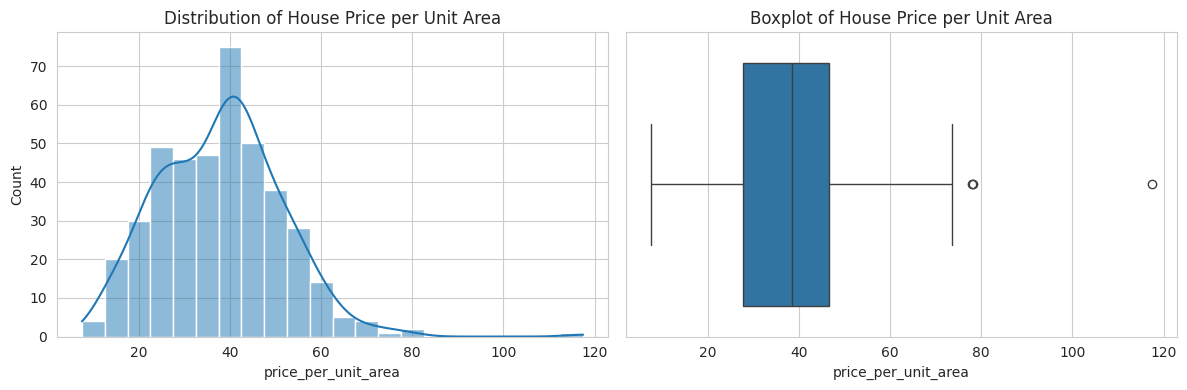

In [ ]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price_per_unit_area"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of House Price per Unit Area")
sns.boxplot(x=df["price_per_unit_area"], ax=axes[1])
axes[1].set_title("Boxplot of House Price per Unit Area")
plt.tight_layout()
plt.show()


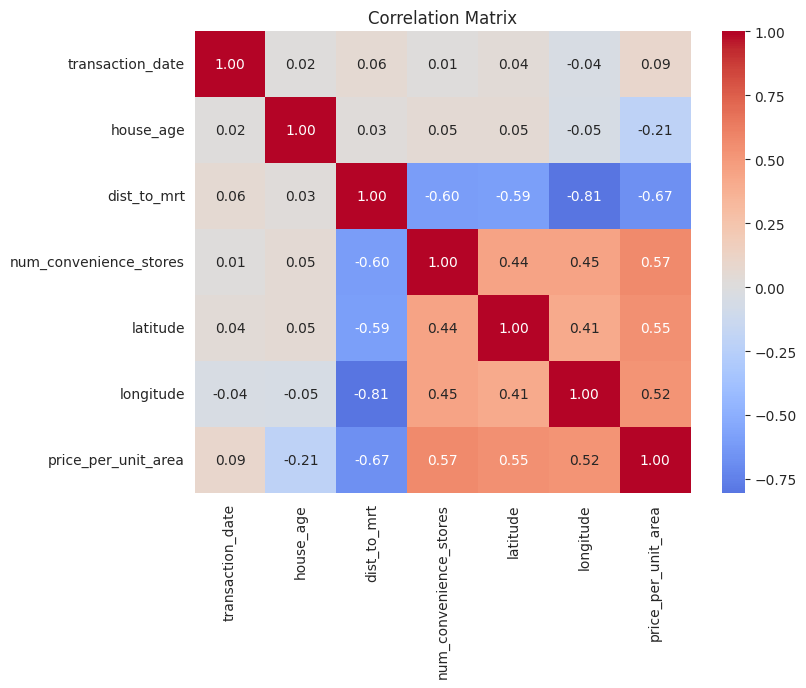

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# Target correlation ranking
corr["price_per_unit_area"].drop("price_per_unit_area").sort_values(key=abs, ascending=False)


,price_per_unit_area
dist_to_mrt,-0.673613
num_convenience_stores,0.571005
latitude,0.546307
longitude,0.523287
house_age,-0.210567
transaction_date,0.087529


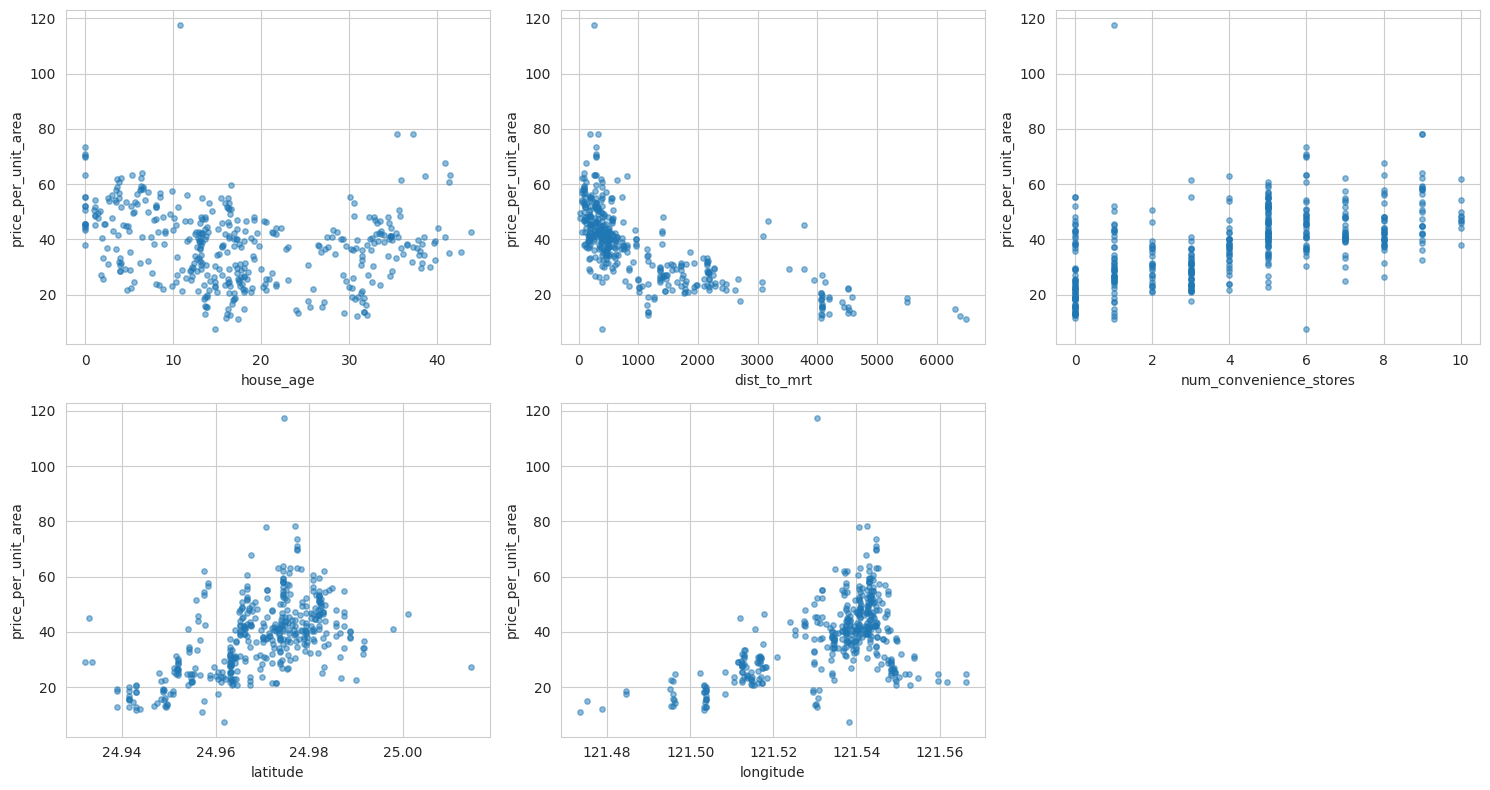

In [ ]:
# Scatter plots of each feature vs target
features = ["house_age", "dist_to_mrt", "num_convenience_stores", "latitude", "longitude"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df["price_per_unit_area"], alpha=0.5, s=15)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("price_per_unit_area")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


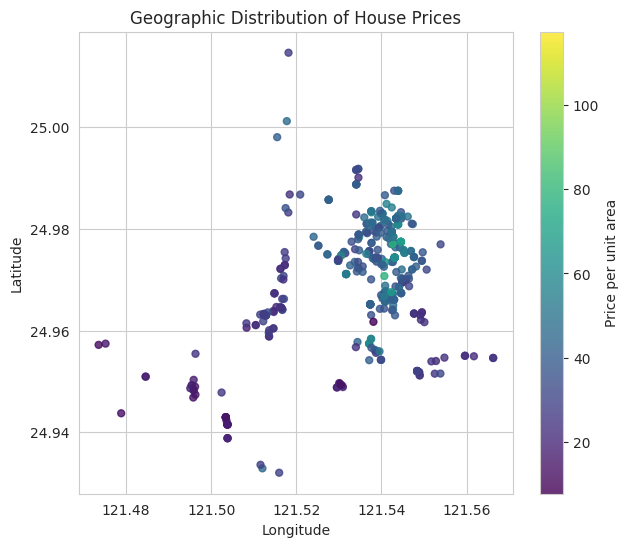

In [ ]:
# Geographic scatter: price by location
plt.figure(figsize=(7, 6))
sc = plt.scatter(df["longitude"], df["latitude"], c=df["price_per_unit_area"],
                  cmap="viridis", s=25, alpha=0.8)
plt.colorbar(sc, label="Price per unit area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of House Prices")
plt.show()


In [ ]:
# Outlier check using IQR on the target
Q1, Q3 = df["price_per_unit_area"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["price_per_unit_area"] < lower) | (df["price_per_unit_area"] > upper)]
print(f"Potential outliers: {len(outliers)} rows")
outliers


Potential outliers: 3 rows


,transaction_date,house_age,dist_to_mrt,num_convenience_stores,latitude,longitude,price_per_unit_area
220,2013.333333,37.2,186.5101,9,24.97703,121.54265,78.3
270,2013.333333,10.8,252.5822,1,24.97460,121.53046,117.5
312,2013.583333,35.4,318.5292,9,24.97071,121.54069,78.0


In [ ]:
# Remove extreme outlier(s) that are likely data errors (e.g., price of 0 or far outside range)
df_clean = df[(df["price_per_unit_area"] >= 5) & (df["price_per_unit_area"] <= 100)].copy()
print("Rows before:", len(df), "| Rows after:", len(df_clean))


Rows before: 414 | Rows after: 413


In [ ]:
def decimal_to_year_month(decimal_year):
    year = int(decimal_year)
    frac = decimal_year - year
    month = int(round(frac * 12)) + 1
    if month > 12:
        month = 12
        year += 1
    return year, month

years_months = df_clean["transaction_date"].apply(decimal_to_year_month)
df_clean["transaction_year"] = years_months.apply(lambda x: x[0])
df_clean["transaction_month"] = years_months.apply(lambda x: x[1])
df_clean[["transaction_date", "transaction_year", "transaction_month"]].head()


,transaction_date,transaction_year,transaction_month
0,2012.916667,2012,12
1,2012.916667,2012,12
2,2013.583333,2013,8
3,2013.500000,2013,7
4,2012.833333,2012,11


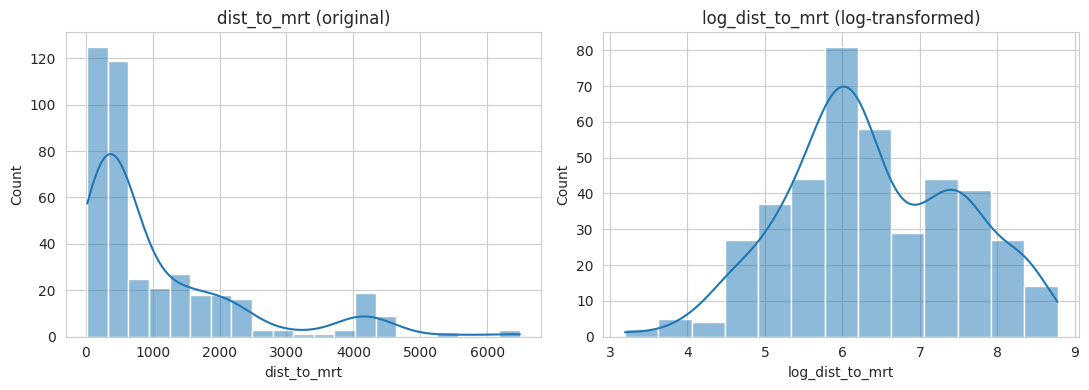

In [ ]:
# Log-transform distance to MRT (right-skewed, spans a wide range)
df_clean["log_dist_to_mrt"] = np.log1p(df_clean["dist_to_mrt"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_clean["dist_to_mrt"], ax=axes[0], kde=True)
axes[0].set_title("dist_to_mrt (original)")
sns.histplot(df_clean["log_dist_to_mrt"], ax=axes[1], kde=True)
axes[1].set_title("log_dist_to_mrt (log-transformed)")
plt.tight_layout()
plt.show()


In [ ]:
# Final feature set
feature_cols = [
    "transaction_date", "house_age", "log_dist_to_mrt",
    "num_convenience_stores", "latitude", "longitude"
]
target_col = "price_per_unit_area"

X = df_clean[feature_cols]
y = df_clean[target_col]
X.head()


,transaction_date,house_age,log_dist_to_mrt,num_convenience_stores,latitude,longitude
0,2012.916667,32.0,4.452937,10,24.98298,121.54024
1,2012.916667,19.5,5.728783,9,24.98034,121.53951
2,2013.583333,13.3,6.333252,5,24.98746,121.54391
3,2013.500000,13.3,6.333252,5,24.98746,121.54391
4,2012.833333,5.0,5.970160,5,24.97937,121.54245


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (330, 6) | Test shape: (83, 6)


In [ ]:
# Standardize features (helps linear/SVR/KNN models; tree models are unaffected but we keep it consistent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=0.1, random_state=RANDOM_STATE),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.5),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf,
                              scoring="neg_root_mean_squared_error")
    cv_results[name] = -scores
    print(f"{name:20s}  CV RMSE: {-scores.mean():.3f} (+/- {scores.std():.3f})")


Linear Regression     CV RMSE: 7.099 (+/- 0.896)
Ridge Regression      CV RMSE: 7.100 (+/- 0.893)
Lasso Regression      CV RMSE: 7.099 (+/- 0.902)
KNN Regressor         CV RMSE: 6.987 (+/- 0.865)
Decision Tree         CV RMSE: 7.759 (+/- 1.593)
Random Forest         CV RMSE: 6.210 (+/- 0.936)
Gradient Boosting     CV RMSE: 6.213 (+/- 1.147)
SVR (RBF)             CV RMSE: 6.753 (+/- 1.012)


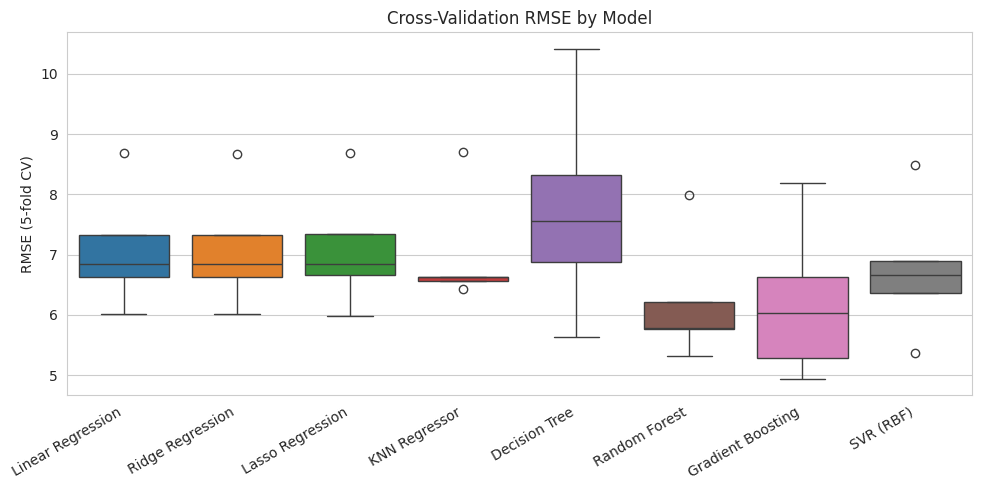

In [ ]:
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(10, 5))
sns.boxplot(data=cv_df)
plt.ylabel("RMSE (5-fold CV)")
plt.title("Cross-Validation RMSE by Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}, preds

results = {}
predictions = {}
for name, model in models.items():
    metrics, preds = evaluate(model, X_train_scaled, y_train, X_test_scaled, y_test)
    results[name] = metrics
    predictions[name] = preds

results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df


,RMSE,MAE,R2
Random Forest,7.014823,4.690229,0.681992
Gradient Boosting,7.215860,4.810976,0.663503
KNN Regressor,7.481440,5.289501,0.638278
Decision Tree,7.528852,5.509755,0.633679
SVR (RBF),7.637063,4.986482,0.623073
Lasso Regression,8.193489,5.196532,0.566147
Ridge Regression,8.194050,5.186716,0.566088
Linear Regression,8.205567,5.195116,0.564867


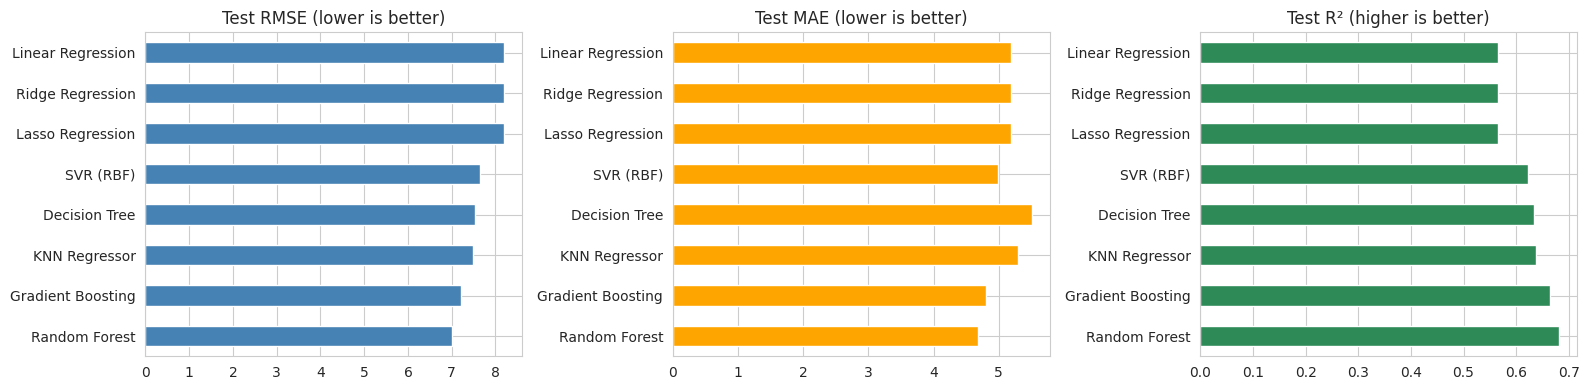

In [ ]:
# Visualize test-set performance
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
results_df["RMSE"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Test RMSE (lower is better)")
results_df["MAE"].plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Test MAE (lower is better)")
results_df["R2"].plot(kind="barh", ax=axes[2], color="seagreen")
axes[2].set_title("Test R² (higher is better)")
plt.tight_layout()
plt.show()


In [ ]:
best_model_name = results_df["RMSE"].idxmin()
print("Best model based on test RMSE:", best_model_name)
results_df.loc[[best_model_name]]


Best model based on test RMSE: Random Forest


,RMSE,MAE,R2
Random Forest,7.014823,4.690229,0.681992


In [ ]:
# Example grid search for Gradient Boosting / Random Forest (adjust depending on best_model_name)
if best_model_name == "Gradient Boosting":
    param_grid = {
        "n_estimators": [200, 300, 500],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.03, 0.05, 0.1],
    }
    base_model = GradientBoostingRegressor(random_state=RANDOM_STATE)
elif best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [200, 300, 500],
        "max_depth": [6, 8, 10, None],
        "min_samples_leaf": [1, 2, 4],
    }
    base_model = RandomForestRegressor(random_state=RANDOM_STATE)
else:
    param_grid = {}
    base_model = models[best_model_name]

if param_grid:
    grid = GridSearchCV(base_model, param_grid, cv=5,
                         scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    print("Best params:", grid.best_params_)
    tuned_model = grid.best_estimator_
else:
    tuned_model = base_model
    tuned_model.fit(X_train_scaled, y_train)

tuned_metrics, tuned_preds = evaluate(tuned_model, X_train_scaled, y_train, X_test_scaled, y_test)
print("Tuned model test performance:", tuned_metrics)


Best params: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Tuned model test performance: {'RMSE': np.float64(7.0680878653132035), 'MAE': 4.772012601922842, 'R2': 0.6771440645058826}


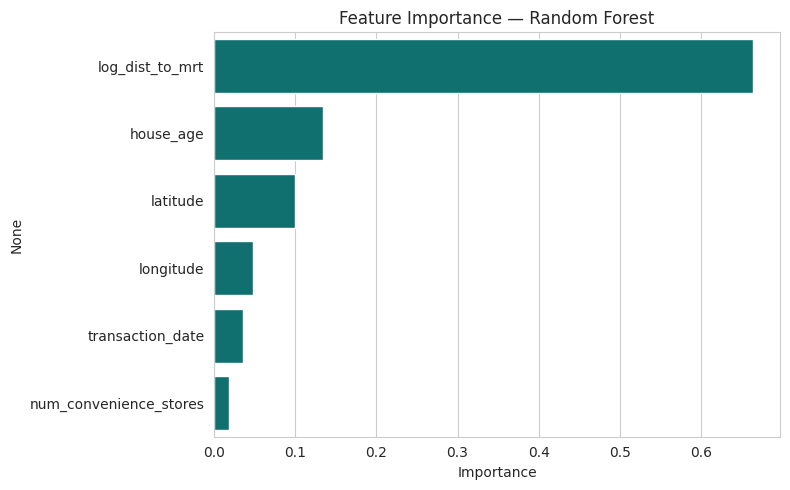

log_dist_to_mrt           0.664323
house_age                 0.134744
latitude                  0.099361
longitude                 0.048122
transaction_date          0.035713
num_convenience_stores    0.017737
dtype: float64


In [ ]:
if hasattr(tuned_model, "feature_importances_"):
    importances = pd.Series(tuned_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, color="teal")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(importances)
elif hasattr(tuned_model, "coef_"):
    coefs = pd.Series(tuned_model.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=coefs.values, y=coefs.index, color="teal")
    plt.title(f"Coefficients — {best_model_name}")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()
    print(coefs)
else:
    print("Selected model does not expose direct feature importances (e.g., SVR/KNN).")


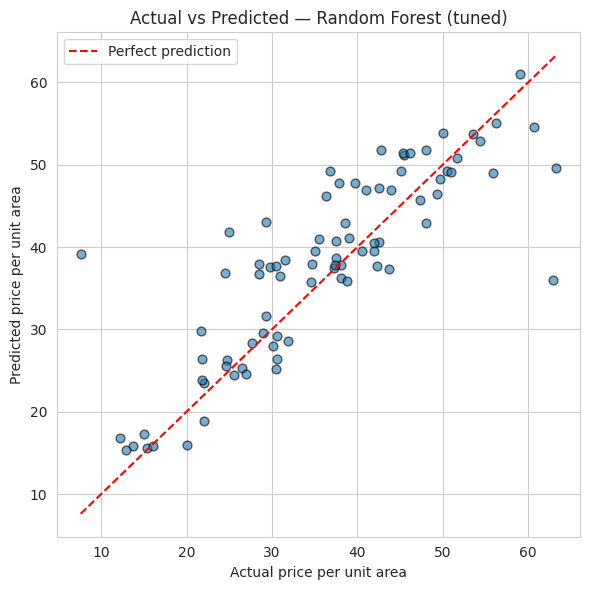

In [ ]:
# Actual vs Predicted plot for the final tuned model
plt.figure(figsize=(6, 6))
plt.scatter(y_test, tuned_preds, alpha=0.6, edgecolor="k", s=40)
lims = [min(y_test.min(), tuned_preds.min()), max(y_test.max(), tuned_preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual price per unit area")
plt.ylabel("Predicted price per unit area")
plt.title(f"Actual vs Predicted — {best_model_name} (tuned)")
plt.legend()
plt.tight_layout()
plt.show()


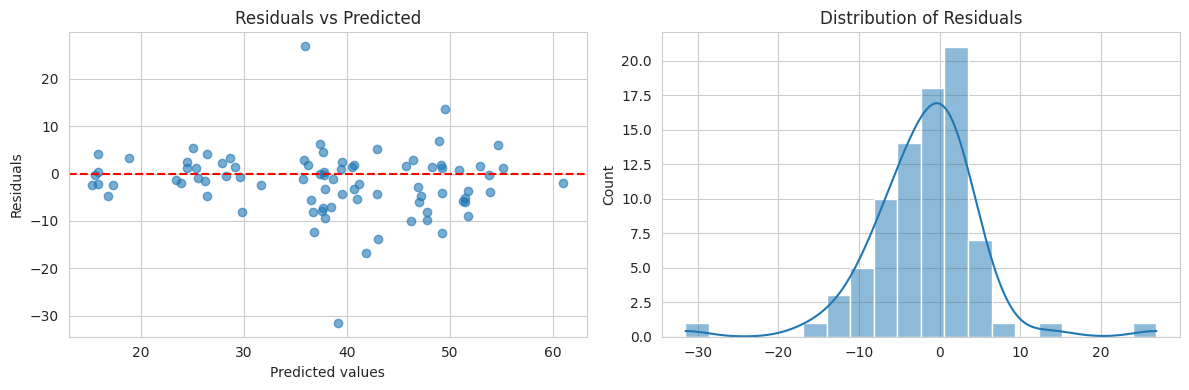

In [ ]:
# Residual analysis
residuals = y_test.values - tuned_preds
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(tuned_preds, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Residuals")
plt.tight_layout()
plt.show()


In [ ]:
# Final summary table
summary = pd.DataFrame({
    "Model": list(results.keys()) + [f"{best_model_name} (tuned)"],
    "RMSE": list(results_df["RMSE"].values) + [tuned_metrics["RMSE"]],
    "MAE": list(results_df["MAE"].values) + [tuned_metrics["MAE"]],
    "R2": list(results_df["R2"].values) + [tuned_metrics["R2"]],
}).sort_values("RMSE").reset_index(drop=True)
summary


,Model,RMSE,MAE,R2
0,Linear Regression,7.014823,4.690229,0.681992
1,Random Forest (tuned),7.068088,4.772013,0.677144
2,Ridge Regression,7.215860,4.810976,0.663503
3,Lasso Regression,7.481440,5.289501,0.638278
4,KNN Regressor,7.528852,5.509755,0.633679
5,Decision Tree,7.637063,4.986482,0.623073
6,Random Forest,8.193489,5.196532,0.566147
7,Gradient Boosting,8.194050,5.186716,0.566088
8,SVR (RBF),8.205567,5.195116,0.564867
